In [2]:
import pandas as pd

In [3]:
df1 = pd.read_excel(r"C:\Users\Dr Mutyala Balaji\Desktop\pap gypsum\PAP 02 gypsym loss prediction after ATA FY 26-27_1st part.xlsx")
df2 = pd.read_excel(r"C:\Users\Dr Mutyala Balaji\Desktop\pap gypsum\PAP 02 gypsym loss prediction after ATA FY 26-27_2nd part.xlsx")

In [4]:
df = pd.concat([df1, df2], ignore_index=True)

print("Combined Shape:", df.shape)

Combined Shape: (43206, 29)


In [5]:
print(df.shape)

(43206, 29)


In [6]:
df.head() 

,Date,Slurry Flow,Slurry SpG,Cake Wash Flow,Weak Wash Flow,Strong Wash flow,HBF Vac Pump Amps,HBF Vac,HBF Current,HBF Speed,...,Sulfuric acid flow,LLFC Temp,LLFC vaccum,A Agitator amps,B Agitator amps,C Agitator amps,D Agitator amps,Reactor B Temp,Reactor D Temp,Throughput
0,2026-04-25 00:00:00,352.282409,1.445889,134.831571,113.071441,97.098238,21.371782,-373.487357,68.483706,647.674196,...,13.192088,77.590151,513.289536,185.993603,202.840445,191.239193,220.505471,77.058719,77.74944,8.188062
1,2026-04-25 00:01:00,359.975596,1.445864,135.983789,105.148127,93.649511,20.825335,-330.207611,66.982794,647.843311,...,10.749223,77.408619,515.616167,182.95435,210.035758,195.472458,219.607988,76.880746,77.60158,6.671825
2,2026-04-25 00:02:00,371.784159,1.445839,134.922587,96.124025,90.413376,20.339652,-299.972683,66.227618,647.645447,...,7.894071,77.262368,518.162337,185.568902,201.615689,201.192488,216.538384,76.675854,77.460858,4.89969
3,2026-04-25 00:03:00,362.652026,1.445814,134.576297,74.859776,87.866867,20.572102,-313.141134,66.520936,647.534161,...,5.077833,77.038011,518.776251,181.554443,192.295411,198.756465,215.676158,76.43858,77.282348,3.151708
4,2026-04-25 00:04:00,370.755418,1.445788,134.655068,69.106184,76.547484,20.921899,-334.346309,66.531847,647.566529,...,1.05456,76.869061,521.818297,182.42332,202.409976,195.263923,220.744931,76.217966,77.122087,0.654544


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43206 entries, 0 to 43205
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          43201 non-null  datetime64[ns]
 1   Slurry Flow                   43201 non-null  object        
 2   Slurry SpG                    43201 non-null  object        
 3   Cake Wash Flow                43201 non-null  object        
 4   Weak Wash  Flow               43202 non-null  object        
 5   Strong Wash flow              43201 non-null  object        
 6   HBF Vac Pump Amps             43201 non-null  object        
 7   HBF Vac                       43201 non-null  object        
 8   HBF Current                   43201 non-null  object        
 9   HBF Speed                     43201 non-null  object        
 10  HBF Air Support               43201 non-null  object        
 11  Filtrate SpG                

In [8]:
# Create copy
df_clean = df.copy()

# Find all object columns
object_cols = df_clean.select_dtypes(include='object').columns

print("Object Columns:")
print(object_cols)

# Convert object columns to numeric
for col in object_cols:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors='coerce'
    )

# Check result
print(df_clean.dtypes)

Object Columns:
Index(['Slurry Flow          ', 'Slurry SpG           ',
       'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow',
       'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ',
       'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ',
       'Solids%            ', 'Free Acid%        ', 'Return Acid         ',
       'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ',
       'Sulfuric acid  flow         ', 'LLFC Temp           ',
       'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ',
       'C Agitator  amps       ', 'D Agitator  amps        ',
       'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput'],
      dtype='object')
Date                            datetime64[ns]
Slurry Flow                            float64
Slurry SpG                             float64
Cake Wash Flow                         float64
Weak Wash  Flow                        float64
Strong Wash flow        

In [9]:
print(df_clean.dtypes.value_counts())

float64           28
datetime64[ns]     1
Name: count, dtype: int64


In [10]:
print(df_clean.isnull().sum().sort_values(ascending=False))

HBF Current                     669
HBF Speed                       669
Free Acid%                      234
Slurry SpG                      233
Filtrate SpG                    113
C Agitator  amps                 36
D Agitator  amps                 36
HBF Vac Pump Amps                10
Sulfuric acid  flow               9
HBF Vac                           8
Weak Wash  Flow                   8
Slurry Flow                       8
Cake Wash Flow                    8
LLFC Temp                         8
Rock  tph                         8
Strong Wash flow                  8
HBF Air Support                   8
Cake Wash Temp                    8
Digestor Temp                     8
Return Acid                       8
Solids%                           8
B Agitator amps                   8
Reactor B Temp                    8
A Agitator  amps                  8
LLFC vaccum                       8
Reactor D Temp                    8
Throughput                        8
Product acid                

In [11]:
df_clean = df_clean.dropna()

print(df_clean.shape)

(42308, 29)


In [12]:
print(df_clean.isnull().sum())

Date                            0
Slurry Flow                     0
Slurry SpG                      0
Cake Wash Flow                  0
Weak Wash  Flow                 0
Strong Wash flow                0
HBF Vac Pump Amps               0
HBF Vac                         0
HBF Current                     0
HBF Speed                       0
HBF Air Support                 0
Filtrate SpG                    0
Product acid                    0
Solids%                         0
Free Acid%                      0
Return Acid                     0
Cake Wash Temp                  0
Digestor Temp                   0
Rock  tph                       0
Sulfuric acid  flow             0
LLFC Temp                       0
LLFC vaccum                     0
A Agitator  amps                0
B Agitator amps                 0
C Agitator  amps                0
D Agitator  amps                0
Reactor B Temp                  0
Reactor D Temp                  0
Throughput                      0
dtype: int64


In [13]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 0


In [14]:
vacuum_cols = [col for col in df_clean.columns if "VAC" in col.upper()]

print(vacuum_cols)

['HBF Vac Pump Amps    ', 'HBF Vac           ', 'LLFC vaccum       ']


In [15]:
numeric_cols = df_clean.select_dtypes(include='number').columns 

for col in numeric_cols:
    neg_count = (df_clean[col] < 0).sum()

    if neg_count > 0:
        print(col, ":", neg_count)

Cake Wash Flow          : 1805
Weak Wash  Flow : 1493
HBF Vac Pump Amps     : 2740
HBF Vac            : 42308
HBF Current       : 2626
HBF Air Support    : 601
Return Acid          : 180
Rock  tph                : 2898
Sulfuric acid  flow          : 3310
LLFC vaccum        : 140
A Agitator  amps : 8
Throughput : 3310


In [16]:
for col in numeric_cols:

    if col not in vacuum_cols:

        df_clean = df_clean[df_clean[col] >= 0]

In [17]:
for col in numeric_cols:

    neg_count = (df_clean[col] < 0).sum()

    if neg_count > 0:
        print(col, ":", neg_count)

HBF Vac            : 38736


In [18]:
print(df_clean.shape)

(38736, 29)


In [19]:
print(vacuum_cols)
print(df_clean.shape)

['HBF Vac Pump Amps    ', 'HBF Vac           ', 'LLFC vaccum       ']
(38736, 29)


In [20]:
import pandas as pd

numeric_cols = df_clean.select_dtypes(include='number').columns

outlier_summary = []

for col in numeric_cols:

    Q1 = df_clean[col].quantile(0.25)

    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ].shape[0]

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Outlier Count"]
)

outlier_df = outlier_df.sort_values(
    by="Outlier Count",
    ascending=False
)

print(outlier_df)

                          Column  Outlier Count
9             HBF Air Support              2557
11         Product acid                    1888
17      Rock  tph                          1678
0          Slurry Flow                     1629
26               Reactor D Temp            1449
2        Cake Wash Flow                    1365
19          LLFC Temp                      1265
25         Reactor B Temp                  1157
5          HBF Vac Pump Amps               1131
18  Sulfuric acid  flow                    1041
27                    Throughput           1027
4               Strong Wash flow           1008
20            LLFC vaccum                   967
1          Slurry SpG                       888
14          Return Acid                     755
10         Filtrate SpG                     747
3                Weak Wash  Flow            550
22      B Agitator amps                     491
21              A Agitator  amps            426
13            Free Acid%                

In [21]:
outlier_df.to_excel(
    "Outlier_Report.xlsx",
    index=False
)

In [22]:
df_clean.describe()

,Date,Slurry Flow,Slurry SpG,Cake Wash Flow,Weak Wash Flow,Strong Wash flow,HBF Vac Pump Amps,HBF Vac,HBF Current,HBF Speed,...,Sulfuric acid flow,LLFC Temp,LLFC vaccum,A Agitator amps,B Agitator amps,C Agitator amps,D Agitator amps,Reactor B Temp,Reactor D Temp,Throughput
count,38736,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,...,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000,38736.000000
mean,2026-05-10 03:45:05.714064640,362.235773,1.453217,122.800086,94.319315,102.954036,21.835078,-399.521858,68.015305,871.217828,...,38.126149,81.396050,463.946234,184.714343,201.379768,195.004609,216.478283,82.564932,80.815698,23.583480
min,2026-04-25 00:00:00,0.041860,1.000679,0.000002,0.040713,0.042985,0.000020,-519.038406,34.465170,203.610573,...,0.005867,63.411567,156.771311,156.442984,174.897367,167.553602,181.348624,57.837047,63.046603,0.003641
25%,2026-05-02 04:27:45,351.783764,1.446458,114.689791,82.866094,79.707731,21.506529,-449.210375,66.614169,797.233242,...,35.545043,80.433385,450.377281,179.704094,196.547878,190.441405,210.640207,81.307069,79.957324,21.978727
50%,2026-05-10 10:24:30,370.141604,1.453913,124.243848,94.749268,119.904347,21.985189,-400.573106,67.887125,945.468244,...,38.903524,81.488268,464.390774,184.249975,200.931937,194.616502,216.694001,82.723409,80.997155,24.071913
75%,2026-05-18 00:27:15,384.720894,1.462471,134.365308,105.499532,129.927228,22.259893,-357.992355,69.379244,951.800810,...,41.507346,82.815364,475.635911,189.352389,205.803919,199.222751,222.426255,84.340188,82.196893,25.675323
max,2026-05-25 00:00:00,477.313325,1.648486,185.740171,214.884418,210.365848,23.544254,-5.062992,77.803650,962.300386,...,56.752950,87.090064,587.748992,222.226179,239.024585,226.936250,251.261754,87.972003,85.949312,35.225407
std,NaN,46.709807,0.022715,17.267604,18.340249,36.268958,0.678863,58.033801,1.714956,107.357279,...,5.264433,2.383824,21.489767,7.266437,7.033328,6.638020,8.507551,2.700861,2.368442,3.254066


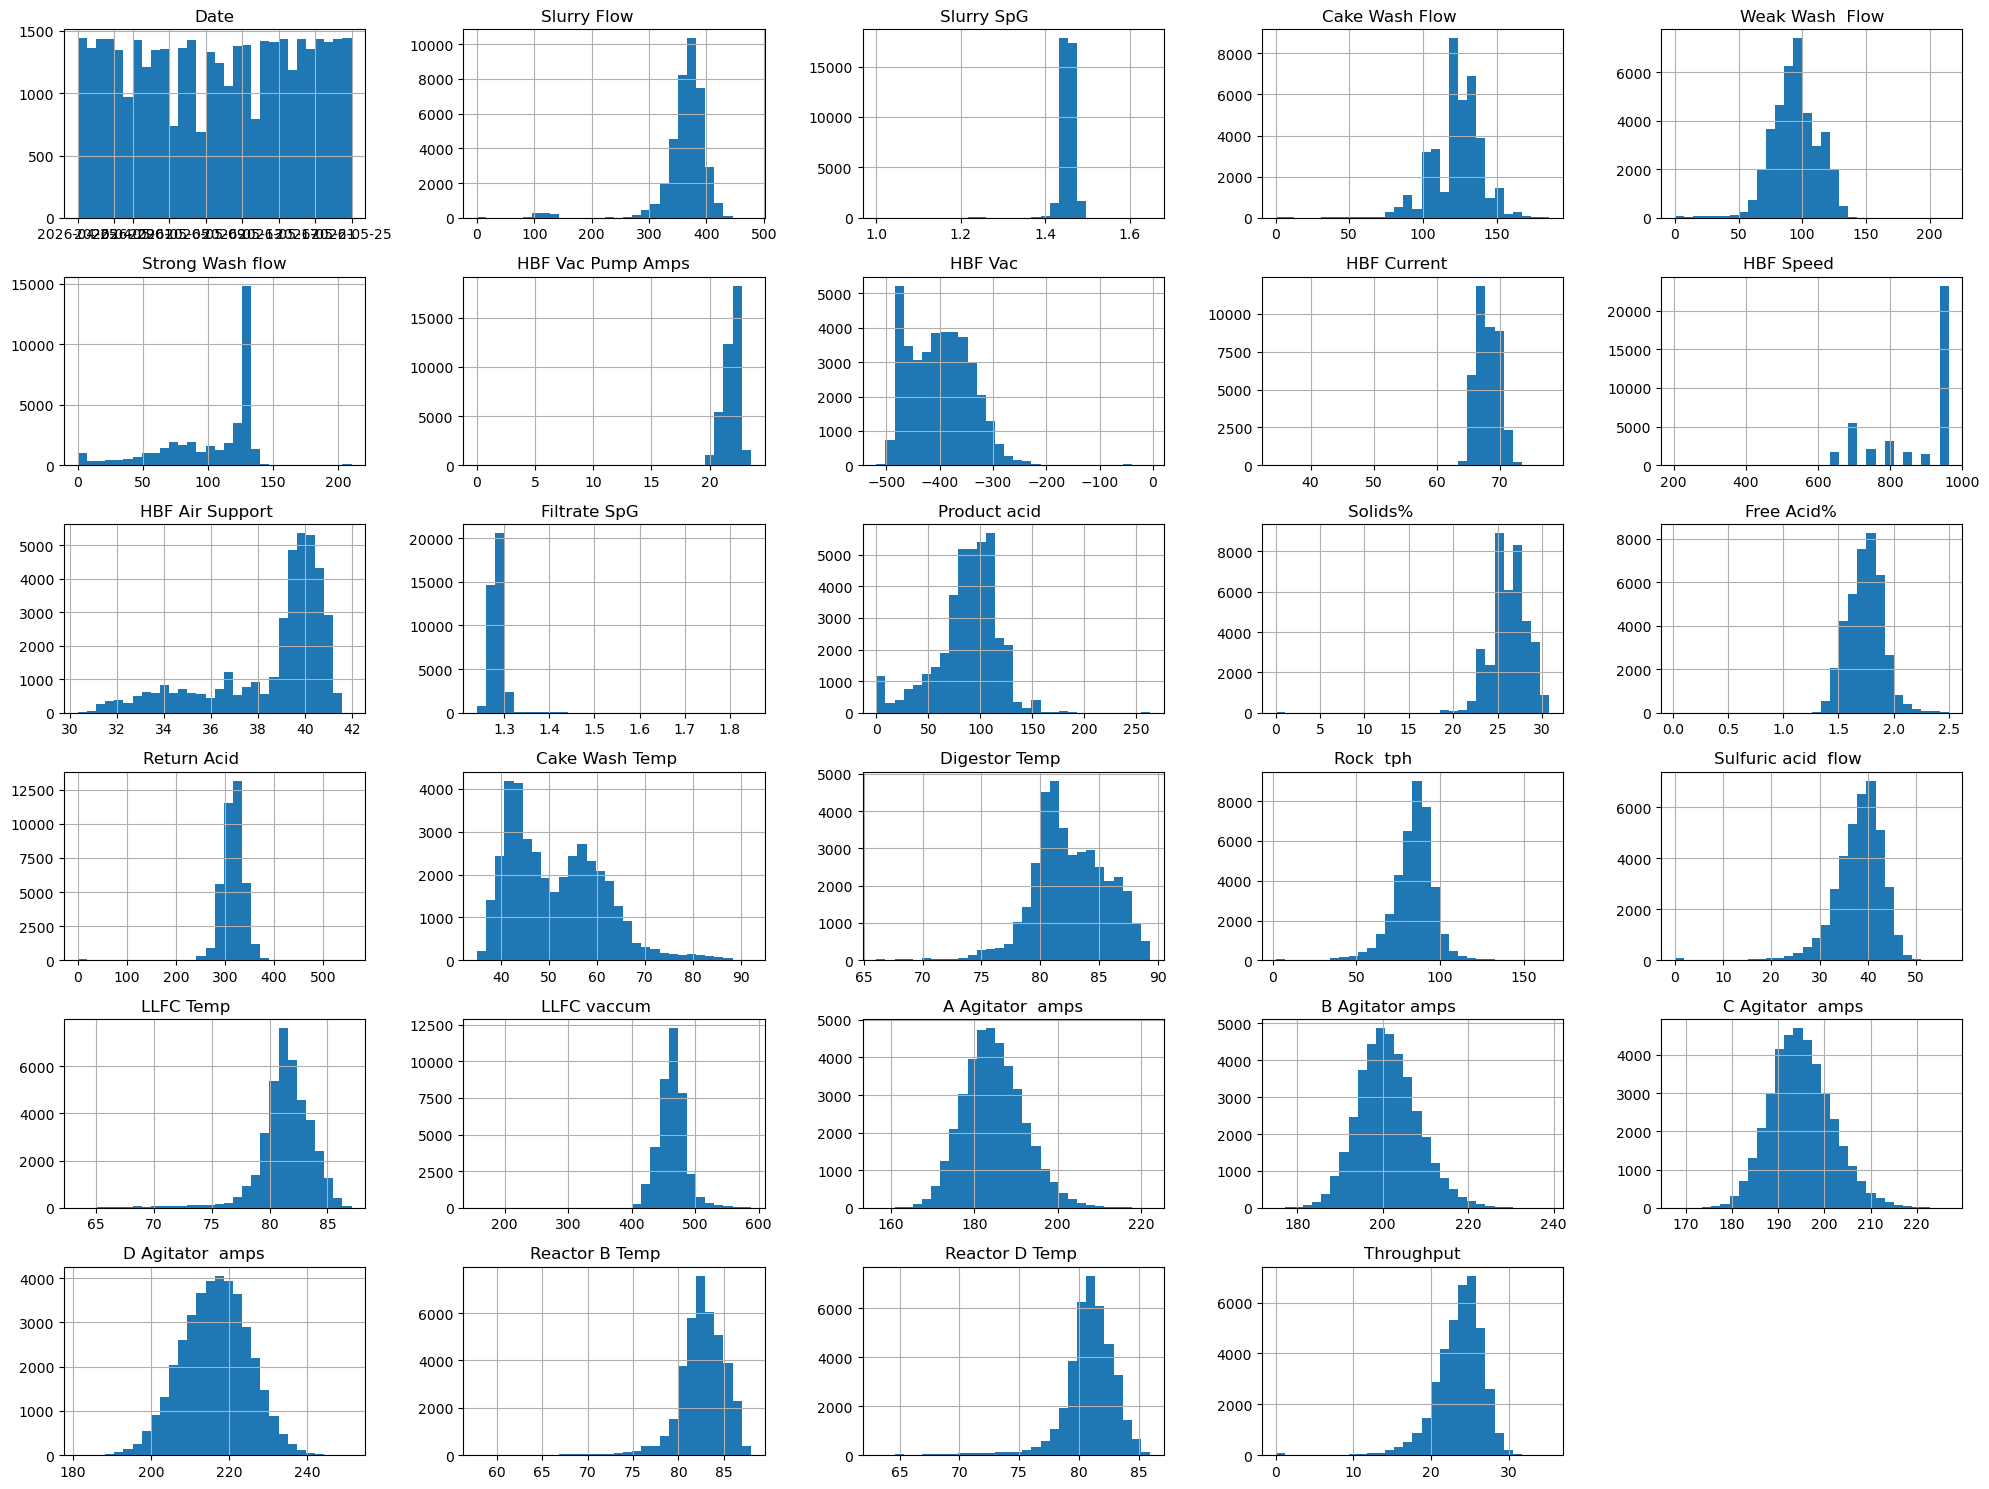

In [23]:
import matplotlib.pyplot as plt

df_clean.hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()

plt.show()

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

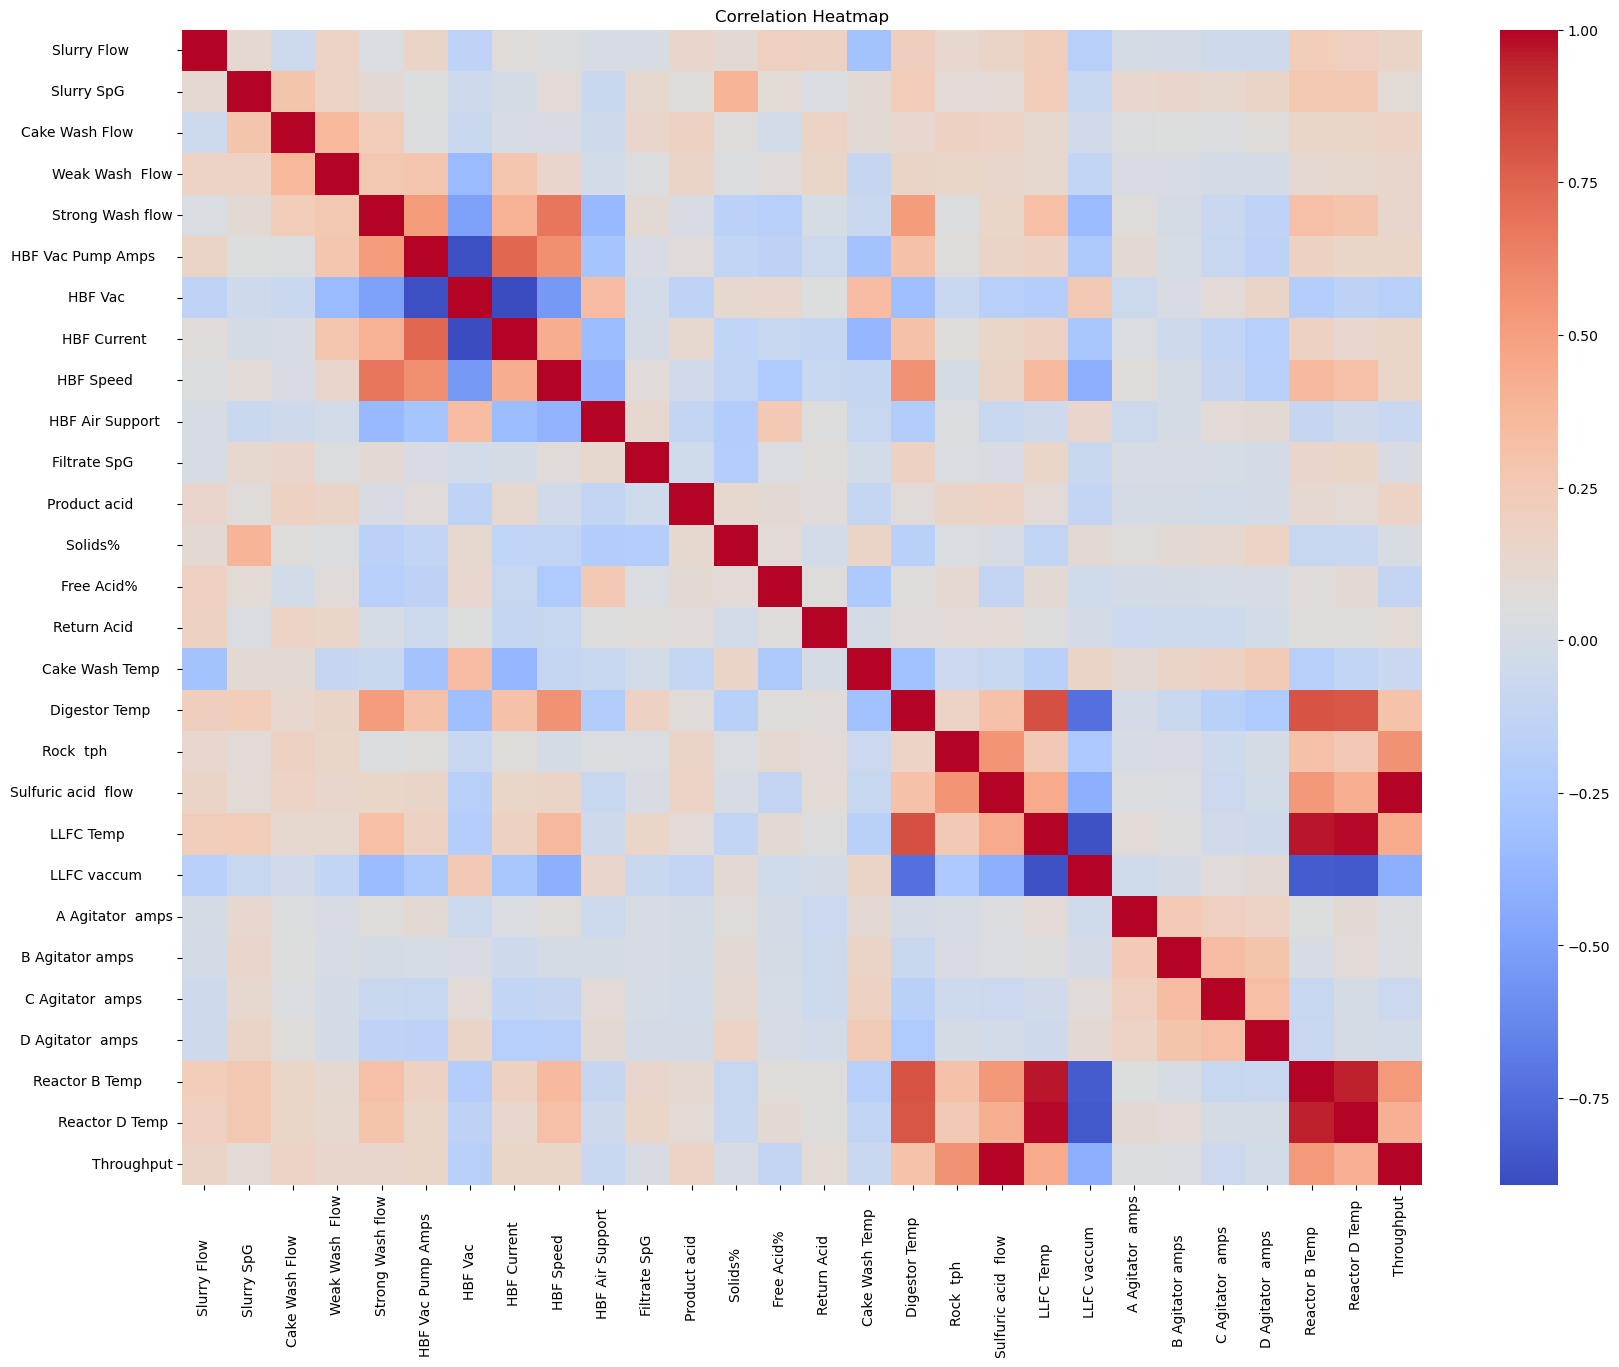

In [25]:
corr = df_clean.corr(
    numeric_only=True
)

plt.figure(figsize=(20,15))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [26]:
import pandas as pd

# Correlation matrix
corr_matrix = df_clean.corr(numeric_only=True)

# Convert to pairs
corr_pairs = corr_matrix.unstack().reset_index()

corr_pairs.columns = [
    'Column_1',
    'Column_2',
    'Correlation'
]

# Remove self correlation
corr_pairs = corr_pairs[
    corr_pairs['Column_1'] != corr_pairs['Column_2']
]

# Create unique pairs
corr_pairs['Pair'] = corr_pairs.apply(
    lambda x: tuple(
        sorted([x['Column_1'], x['Column_2']])
    ),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates('Pair')

# Positive correlations
positive_corr = corr_pairs[
    corr_pairs['Correlation'] > 0.5
].sort_values(
    by='Correlation',
    ascending=False
)

# Negative correlations
negative_corr = corr_pairs[
    corr_pairs['Correlation'] < -0.5
].sort_values(
    by='Correlation'
)

# No correlation
no_corr = corr_pairs[
    (corr_pairs['Correlation'] >= -0.1) &
    (corr_pairs['Correlation'] <= 0.1)
]

print("Positive:", positive_corr.shape)
print("Negative:", negative_corr.shape)
print("No Correlation:", no_corr.shape)

Positive: (17, 4)
Negative: (7, 4)
No Correlation: (165, 4)


In [27]:
print(positive_corr.head(10))

                         Column_1               Column_2  Correlation  \
531  Sulfuric acid  flow                      Throughput     0.999565   
558          LLFC Temp                   Reactor D Temp      0.992599   
557          LLFC Temp             Reactor B Temp            0.963443   
726         Reactor B Temp               Reactor D Temp      0.952623   
467            Digestor Temp        LLFC Temp                0.820604   
473            Digestor Temp       Reactor B Temp            0.805902   
474            Digestor Temp             Reactor D Temp      0.796721   
147         HBF Vac Pump Amps          HBF Current           0.739093   
120              Strong Wash flow     HBF Speed              0.675867   
148         HBF Vac Pump Amps         HBF Speed              0.574705   

                                              Pair  
531     (Sulfuric acid  flow         , Throughput)  
558        (LLFC Temp           , Reactor D Temp )  
557  (LLFC Temp           , Reactor B

In [28]:
print(negative_corr.head(10))

                  Column_1               Column_2  Correlation  \
175     HBF Vac                 HBF Current          -0.891703   
146  HBF Vac Pump Amps         HBF Vac               -0.873792   
552   LLFC Temp                LLFC vaccum           -0.868095   
586     LLFC vaccum               Reactor D Temp     -0.839384   
585     LLFC vaccum         Reactor B Temp           -0.822316   
468     Digestor Temp          LLFC vaccum           -0.735469   
176     HBF Vac                HBF Speed             -0.542872   

                                            Pair  
175      (HBF Current      , HBF Vac           )  
146  (HBF Vac           , HBF Vac Pump Amps    )  
552   (LLFC Temp           , LLFC vaccum       )  
586        (LLFC vaccum       , Reactor D Temp )  
585  (LLFC vaccum       , Reactor B Temp       )  
468     (Digestor Temp     , LLFC vaccum       )  
176     (HBF Speed         , HBF Vac           )  


In [29]:
print(no_corr.head(10))

                 Column_1                  Column_2  Correlation  \
2   Slurry Flow             Cake Wash Flow             -0.055316   
4   Slurry Flow                    Strong Wash flow     0.027322   
7   Slurry Flow                   HBF Current           0.073084   
8   Slurry Flow                  HBF Speed              0.044107   
9   Slurry Flow                  HBF Air Support        0.014120   
10  Slurry Flow               Filtrate SpG              0.014616   
21  Slurry Flow                    A Agitator  amps    -0.004400   
22  Slurry Flow            B Agitator amps             -0.013886   
23  Slurry Flow             C Agitator  amps           -0.044678   
24  Slurry Flow            D Agitator  amps            -0.043820   

                                                 Pair  
2    (Cake Wash Flow         , Slurry Flow          )  
4           (Slurry Flow          , Strong Wash flow)  
7          (HBF Current      , Slurry Flow          )  
8         (HBF Speed       

In [30]:
with pd.ExcelWriter(
    "Correlation_Report.xlsx"
) as writer:

    positive_corr.to_excel(
        writer,
        sheet_name="Positive",
        index=False
    )

    negative_corr.to_excel(
        writer,
        sheet_name="Negative",
        index=False
    )

    no_corr.to_excel(
        writer,
        sheet_name="No_Correlation",
        index=False
    )

In [31]:
print("\nTop 10 Positive Correlations")
print(
    positive_corr[
        ['Column_1','Column_2','Correlation']
    ].head(10)
)

print("\nTop 10 Negative Correlations")
print(
    negative_corr[
        ['Column_1','Column_2','Correlation']
    ].head(10)
)


Top 10 Positive Correlations
                         Column_1               Column_2  Correlation
531  Sulfuric acid  flow                      Throughput     0.999565
558          LLFC Temp                   Reactor D Temp      0.992599
557          LLFC Temp             Reactor B Temp            0.963443
726         Reactor B Temp               Reactor D Temp      0.952623
467            Digestor Temp        LLFC Temp                0.820604
473            Digestor Temp       Reactor B Temp            0.805902
474            Digestor Temp             Reactor D Temp      0.796721
147         HBF Vac Pump Amps          HBF Current           0.739093
120              Strong Wash flow     HBF Speed              0.675867
148         HBF Vac Pump Amps         HBF Speed              0.574705

Top 10 Negative Correlations
                  Column_1               Column_2  Correlation
175     HBF Vac                 HBF Current          -0.891703
146  HBF Vac Pump Amps         HBF Vac      

In [32]:
print(df.columns.tolist())


['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids%            ', 'Free Acid%        ', 'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ', 'Sulfuric acid  flow         ', 'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ', 'C Agitator  amps       ', 'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput']


In [33]:
print(df_clean.columns.tolist())

['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids%            ', 'Free Acid%        ', 'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ', 'Sulfuric acid  flow         ', 'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ', 'C Agitator  amps       ', 'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput']


In [34]:
for col in df.columns:
    print(repr(col))

'Date'
'Slurry Flow          '
'Slurry SpG           '
'Cake Wash Flow         '
'Weak Wash  Flow'
'Strong Wash flow'
'HBF Vac Pump Amps    '
'HBF Vac           '
'HBF Current      '
'HBF Speed         '
'HBF Air Support   '
'Filtrate SpG         '
'Product acid         '
'Solids%            '
'Free Acid%        '
'Return Acid         '
'Cake Wash Temp   '
'Digestor Temp     '
'Rock  tph               '
'Sulfuric acid  flow         '
'LLFC Temp           '
'LLFC vaccum       '
'A Agitator  amps'
'B Agitator amps         '
'C Agitator  amps       '
'D Agitator  amps        '
'Reactor B Temp       '
'Reactor D Temp '
'Throughput'


In [35]:
print(df_clean.columns.tolist())

['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids%            ', 'Free Acid%        ', 'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ', 'Sulfuric acid  flow         ', 'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ', 'C Agitator  amps       ', 'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput']


In [36]:
for col in df_clean.columns:
    print(repr(col))

'Date'
'Slurry Flow          '
'Slurry SpG           '
'Cake Wash Flow         '
'Weak Wash  Flow'
'Strong Wash flow'
'HBF Vac Pump Amps    '
'HBF Vac           '
'HBF Current      '
'HBF Speed         '
'HBF Air Support   '
'Filtrate SpG         '
'Product acid         '
'Solids%            '
'Free Acid%        '
'Return Acid         '
'Cake Wash Temp   '
'Digestor Temp     '
'Rock  tph               '
'Sulfuric acid  flow         '
'LLFC Temp           '
'LLFC vaccum       '
'A Agitator  amps'
'B Agitator amps         '
'C Agitator  amps       '
'D Agitator  amps        '
'Reactor B Temp       '
'Reactor D Temp '
'Throughput'


In [37]:
print(type(df_clean))
print(df_clean.shape)

<class 'pandas.core.frame.DataFrame'>
(38736, 29)


In [38]:
print(df_clean.head())

                 Date  Slurry Flow            Slurry SpG             \
0 2026-04-25 00:00:00             352.282409               1.445889   
1 2026-04-25 00:01:00             359.975596               1.445864   
2 2026-04-25 00:02:00             371.784159               1.445839   
3 2026-04-25 00:03:00             362.652026               1.445814   
4 2026-04-25 00:04:00             370.755418               1.445788   

   Cake Wash Flow           Weak Wash  Flow  Strong Wash flow  \
0               134.831571       113.071441         97.098238   
1               135.983789       105.148127         93.649511   
2               134.922587        96.124025         90.413376   
3               134.576297        74.859776         87.866867   
4               134.655068        69.106184         76.547484   

   HBF Vac Pump Amps      HBF Vac             HBF Current        \
0              21.371782         -373.487357          68.483706   
1              20.825335         -330.207611    

In [39]:
print("Original DataFrame:")
print(df.columns.tolist())

print("\nCleaned DataFrame:")
print(df_clean.columns.tolist())

Original DataFrame:
['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids%            ', 'Free Acid%        ', 'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ', 'Sulfuric acid  flow         ', 'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ', 'C Agitator  amps       ', 'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput']

Cleaned DataFrame:
['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids

In [40]:
for col in df_clean.columns:
    if "Free" in col:
        print(repr(col))

'Free Acid%        '


In [41]:
df_clean.columns = df_clean.columns.str.strip()

In [42]:
for col in df_clean.columns:
    if "Free" in col:
        print(repr(col))

'Free Acid%'


In [43]:
y = df_clean['Free Acid%']

X = df_clean.drop('Free Acid%', axis=1)

print(X.shape)
print(y.shape)

(38736, 28)
(38736,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (27115, 28)
Validation: (3873, 28)
Test: (7748, 28)


In [45]:
print(X_train.select_dtypes(include=['datetime64']).columns)

Index(['Date'], dtype='object')


In [46]:
X = X.drop(columns=['Date'])

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [48]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42
)

In [49]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (27115, 27)
Validation: (3873, 27)
Test: (7748, 27)


In [50]:
print(X.dtypes)

Slurry Flow            float64
Slurry SpG             float64
Cake Wash Flow         float64
Weak Wash  Flow        float64
Strong Wash flow       float64
HBF Vac Pump Amps      float64
HBF Vac                float64
HBF Current            float64
HBF Speed              float64
HBF Air Support        float64
Filtrate SpG           float64
Product acid           float64
Solids%                float64
Return Acid            float64
Cake Wash Temp         float64
Digestor Temp          float64
Rock  tph              float64
Sulfuric acid  flow    float64
LLFC Temp              float64
LLFC vaccum            float64
A Agitator  amps       float64
B Agitator amps        float64
C Agitator  amps       float64
D Agitator  amps       float64
Reactor B Temp         float64
Reactor D Temp         float64
Throughput             float64
dtype: object


In [51]:
y = df_clean['Free Acid%']

X = df_clean.drop('Free Acid%', axis=1)

In [52]:
print(X.dtypes)

Date                   datetime64[ns]
Slurry Flow                   float64
Slurry SpG                    float64
Cake Wash Flow                float64
Weak Wash  Flow               float64
Strong Wash flow              float64
HBF Vac Pump Amps             float64
HBF Vac                       float64
HBF Current                   float64
HBF Speed                     float64
HBF Air Support               float64
Filtrate SpG                  float64
Product acid                  float64
Solids%                       float64
Return Acid                   float64
Cake Wash Temp                float64
Digestor Temp                 float64
Rock  tph                     float64
Sulfuric acid  flow           float64
LLFC Temp                     float64
LLFC vaccum                   float64
A Agitator  amps              float64
B Agitator amps               float64
C Agitator  amps              float64
D Agitator  amps              float64
Reactor B Temp                float64
Reactor D Te

In [53]:
X = df_clean.drop(['Free Acid%', 'Date'], axis=1)
y = df_clean['Free Acid%']

In [54]:
print(X.dtypes)

Slurry Flow            float64
Slurry SpG             float64
Cake Wash Flow         float64
Weak Wash  Flow        float64
Strong Wash flow       float64
HBF Vac Pump Amps      float64
HBF Vac                float64
HBF Current            float64
HBF Speed              float64
HBF Air Support        float64
Filtrate SpG           float64
Product acid           float64
Solids%                float64
Return Acid            float64
Cake Wash Temp         float64
Digestor Temp          float64
Rock  tph              float64
Sulfuric acid  flow    float64
LLFC Temp              float64
LLFC vaccum            float64
A Agitator  amps       float64
B Agitator amps        float64
C Agitator  amps       float64
D Agitator  amps       float64
Reactor B Temp         float64
Reactor D Temp         float64
Throughput             float64
dtype: object


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42
)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [57]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(27115, 27)
(3873, 27)
(7748, 27)


In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
lr = LinearRegression()

In [60]:
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [61]:
y_pred = lr.predict(X_test_scaled)

In [62]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.28149413664273104
MAE: 0.10306811770172242
RMSE: 0.13558225230731913


In [63]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

     Actual  Predicted
0  1.732121   1.836586
1  1.895184   1.801531
2  1.828739   1.734669
3  1.712764   1.630098
4  2.373656   1.749172
5  1.763151   1.856305
6  1.791186   1.778315
7  2.002723   1.830212
8  1.722043   1.767171
9  1.642671   1.766408


In [64]:
train_r2 = lr.score(X_train_scaled, y_train)
print(train_r2)

0.289521587475867


In [65]:
test_r2 = lr.score(X_test_scaled, y_test)
print(test_r2)

0.28149413664273104


In [66]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [67]:
# Training Performance
train_r2 = lr.score(X_train_scaled, y_train)

# Testing Performance
test_r2 = lr.score(X_test_scaled, y_test)

print("Train R² Score:", train_r2)
print("Test R² Score :", test_r2)

Train R² Score: 0.289521587475867
Test R² Score : 0.28149413664273104


In [68]:
from sklearn.linear_model import Ridge

In [69]:
ridge = Ridge(alpha=1.0)

In [70]:
ridge.fit(X_train_scaled, y_train)

Ridge()

In [71]:
y_train_pred = ridge.predict(X_train_scaled)

y_test_pred = ridge.predict(X_test_scaled)

In [72]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Training Metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing Metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("===== Training Performance =====")
print("R² Score :", train_r2)
print("MAE      :", train_mae)
print("RMSE     :", train_rmse)

print("\n===== Testing Performance =====")
print("R² Score :", test_r2)
print("MAE      :", test_mae)
print("RMSE     :", test_rmse)

===== Training Performance =====
R² Score : 0.28951648800342855
MAE      : 0.10350828284319205
RMSE     : 0.1371238654043296

===== Testing Performance =====
R² Score : 0.2814978598847532
MAE      : 0.10307228860175366
RMSE     : 0.13558190101847173


In [73]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)

lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.001)

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R² :", r2_score(y_test, y_test_pred))

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE :", mean_absolute_error(y_test, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train R²: 0.27751690855856426
Test R² : 0.27117337829888377
Train MAE: 0.10492881343783524
Test MAE : 0.1044237364002876
Train RMSE: 0.1382769809980161
Test RMSE : 0.13655254531794078


In [75]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

print(coef_df)

                Feature  Coefficient
0           Slurry Flow     0.013517
1            Slurry SpG     0.007411
2        Cake Wash Flow    -0.004818
3       Weak Wash  Flow     0.012898
4      Strong Wash flow    -0.007604
5     HBF Vac Pump Amps    -0.009371
6               HBF Vac     0.009737
7           HBF Current     0.002743
8             HBF Speed    -0.025794
9       HBF Air Support     0.024737
10         Filtrate SpG     0.000000
11         Product acid     0.011513
12              Solids%     0.017036
13          Return Acid    -0.000000
14       Cake Wash Temp    -0.034265
15        Digestor Temp     0.017220
16            Rock  tph     0.027177
17  Sulfuric acid  flow    -0.046150
18            LLFC Temp     0.020672
19          LLFC vaccum     0.000000
20     A Agitator  amps     0.001468
21      B Agitator amps     0.003034
22     C Agitator  amps    -0.000000
23     D Agitator  amps    -0.000000
24       Reactor B Temp    -0.000000
25       Reactor D Temp    -0.000000
2

In [76]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [77]:
y_train_pred = dt.predict(X_train)

y_test_pred = dt.predict(X_test)

In [78]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2) 

print("Test R²:", test_r2)

Train R²: 1.0
Test R²: 0.9000126664155651


In [79]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [80]:
from sklearn.metrics import r2_score

# Predictions
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# R² Scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R² Score:", train_r2)
print("Test R² Score :", test_r2)

Train R² Score: 0.7438628513993526
Test R² Score : 0.6884175975135993


In [81]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

depths = [3, 5, 7, 10, 15, 20, None]

for depth in depths:

    dt = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train, y_train)

    train_r2 = dt.score(X_train, y_train)
    test_r2 = dt.score(X_test, y_test)

    print(f"Depth = {depth}")
    print(f"Train R² = {train_r2:.4f}")
    print(f"Test R²  = {test_r2:.4f}")
    print("-"*30)

Depth = 3
Train R² = 0.2445
Test R²  = 0.2341
------------------------------
Depth = 5
Train R² = 0.3611
Test R²  = 0.3378
------------------------------
Depth = 7
Train R² = 0.4933
Test R²  = 0.4800
------------------------------
Depth = 10
Train R² = 0.7439
Test R²  = 0.6884
------------------------------
Depth = 15
Train R² = 0.9572
Test R²  = 0.8715
------------------------------
Depth = 20
Train R² = 0.9950
Test R²  = 0.9055
------------------------------
Depth = None
Train R² = 1.0000
Test R²  = 0.9000
------------------------------


In [82]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [83]:
y_train_pred = rf.predict(X_train)

y_test_pred = rf.predict(X_test)

In [84]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.9953050656797281
Test R² : 0.9703438196524857


In [85]:
import sys
print(sys.executable)

c:\anaconda\python.exe


In [86]:
import sys
print(sys.executable)

c:\anaconda\python.exe


In [87]:
import platform
print(platform.python_version())

3.13.5


In [88]:
import sys

!"{sys.executable}" -m pip install xgboost

In [89]:
from xgboost import XGBRegressor

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [90]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [91]:
from sklearn.metrics import r2_score

y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.899462336125474
Test R² : 0.8739946314491794


In [92]:
import sys

!"{sys.executable}" -m pip install tensorflow

In [93]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [94]:
import sys

!"{sys.executable}" -m pip install tensorflow

In [95]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    
    Dense(32, activation='relu', input_shape=(27,)),
    
    Dense(16, activation='relu'),
    
    Dense(1)
])

c:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [99]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


848/848 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2345 - mae: 0.3099 - val_loss: 0.0462 - val_mae: 0.1677
Epoch 2/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0344 - mae: 0.1401 - val_loss: 0.0240 - val_mae: 0.1200
Epoch 3/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0214 - mae: 0.1100 - val_loss: 0.0182 - val_mae: 0.1035
Epoch 4/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0176 - mae: 0.0994 - val_loss: 0.0160 - val_mae: 0.0964
Epoch 5/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0159 - mae: 0.0946 - val_loss: 0.0154 - val_mae: 0.0938
Epoch 6/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0148 - mae: 0.0911 - val_loss: 0.0163 - val_mae: 0.0987
Epoch 7/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0139 - mae: 0.0885 - val_loss: 0.0140 - val_mae: 0.0893
Epoch 8/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0134 - mae: 0.0867 - val_loss: 0.0132 - val_mae: 0.0879
Epoch 9/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0127 

In [100]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(27115, 27)
(3873, 27)
(7748, 27)


In [101]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    
    Dense(32, activation='relu', input_shape=(27,)),
    
    Dense(16, activation='relu'),
    
    Dense(1)
])

c:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [103]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [105]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1591 - mae: 0.2646 - val_loss: 0.0355 - val_mae: 0.1448
Epoch 2/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0276 - mae: 0.1251 - val_loss: 0.0223 - val_mae: 0.1155
Epoch 3/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0196 - mae: 0.1062 - val_loss: 0.0188 - val_mae: 0.1057
Epoch 4/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0167 - mae: 0.0981 - val_loss: 0.0163 - val_mae: 0.0989
Epoch 5/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0152 - mae: 0.0932 - val_loss: 0.0148 - val_mae: 0.0935
Epoch 6/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0142 - mae: 0.0902 - val_loss: 0.0138 - val_mae: 0.0907
Epoch 7/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0133 - mae: 0.0870 - val_loss: 0.0126 - val_mae: 0.0858
Epoch 8/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0127 - mae: 0.0850 - val_loss: 0.0127 - val_mae: 0.0866
Epoch 9/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [106]:
y_pred = model.predict(X_test_scaled)

243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [107]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("ANN Test R²:", r2)

ANN Test R²: 0.7455518363963307


In [108]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
9,HBF Air Support,0.177239
1,Slurry SpG,0.108582
10,Filtrate SpG,0.086485
15,Digestor Temp,0.080361
12,Solids%,0.079752
8,HBF Speed,0.066130
14,Cake Wash Temp,0.053529
19,LLFC vaccum,0.035497
11,Product acid,0.034058
25,Reactor D Temp,0.028972


In [109]:
import sys

!"{sys.executable}" -m pip install shap

In [110]:
import shap

print(shap.__version__)

0.52.0


In [111]:
explainer = shap.TreeExplainer(rf)

In [112]:
import pandas as pd

In [113]:
df['Date'] = pd.to_datetime(df['Date'])

In [114]:
df = df.sort_values('Date')

In [115]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [116]:
print("Number of trees used:", random_forest.n_estimators)

Number of trees used: 100


In [117]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

predictions = random_forest.predict(X_test)

print("Model Trained Successfully!")

Model Trained Successfully!


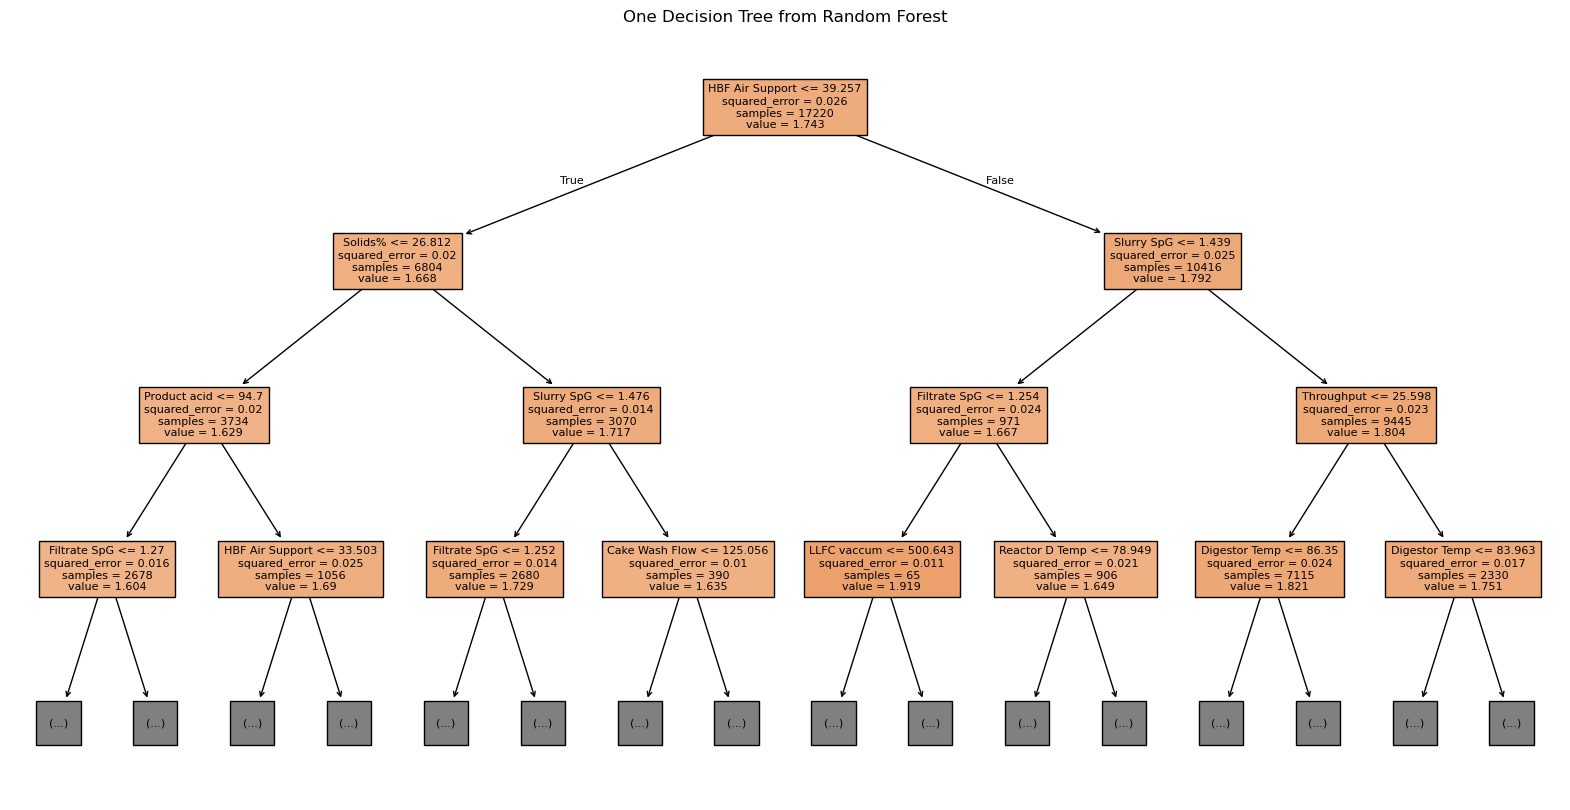

In [118]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    random_forest.estimators_[0],
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("One Decision Tree from Random Forest")
plt.show()

In [119]:
print("Number of Trees Used :", random_forest.n_estimators)

print("Trees Actually Built :", len(random_forest.estimators_))

Number of Trees Used : 100
Trees Actually Built : 100


                Feature  Importance
9       HBF Air Support    0.177239
1            Slurry SpG    0.108582
10         Filtrate SpG    0.086485
15        Digestor Temp    0.080361
12              Solids%    0.079752
8             HBF Speed    0.066130
14       Cake Wash Temp    0.053529
19          LLFC vaccum    0.035497
11         Product acid    0.034058
25       Reactor D Temp    0.028972
2        Cake Wash Flow    0.027840
0           Slurry Flow    0.026187
26           Throughput    0.025849
24       Reactor B Temp    0.024467
13          Return Acid    0.023119
17  Sulfuric acid  flow    0.022493
6               HBF Vac    0.018491
18            LLFC Temp    0.017187
5     HBF Vac Pump Amps    0.014746
16            Rock  tph    0.013288
3       Weak Wash  Flow    0.012015
7           HBF Current    0.011997
4      Strong Wash flow    0.006790
20     A Agitator  amps    0.001357
21      B Agitator amps    0.001228
23     D Agitator  amps    0.001206
22     C Agitator  amps    0

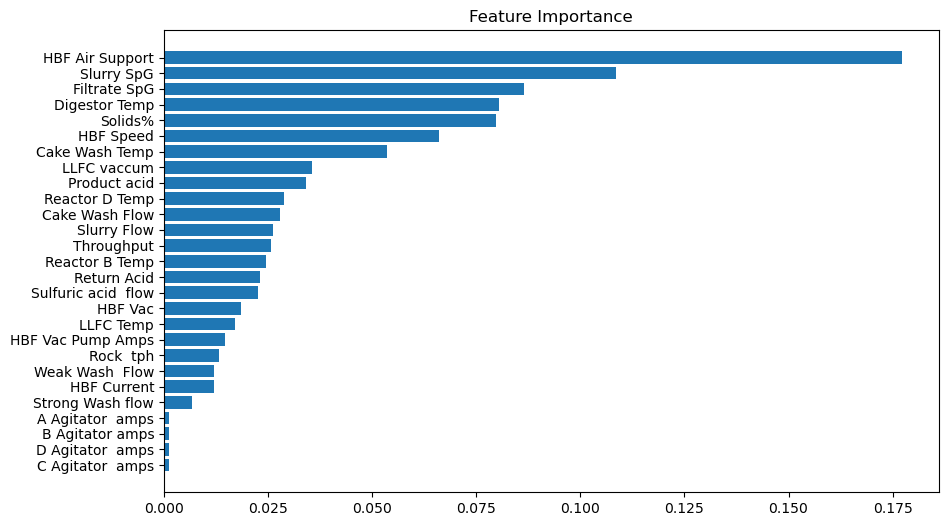

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(10,6))

plt.barh(importance["Feature"], importance["Importance"])

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

In [121]:
print(df.shape)

(43206, 29)


In [122]:
print(X_test.shape)

(7748, 27)


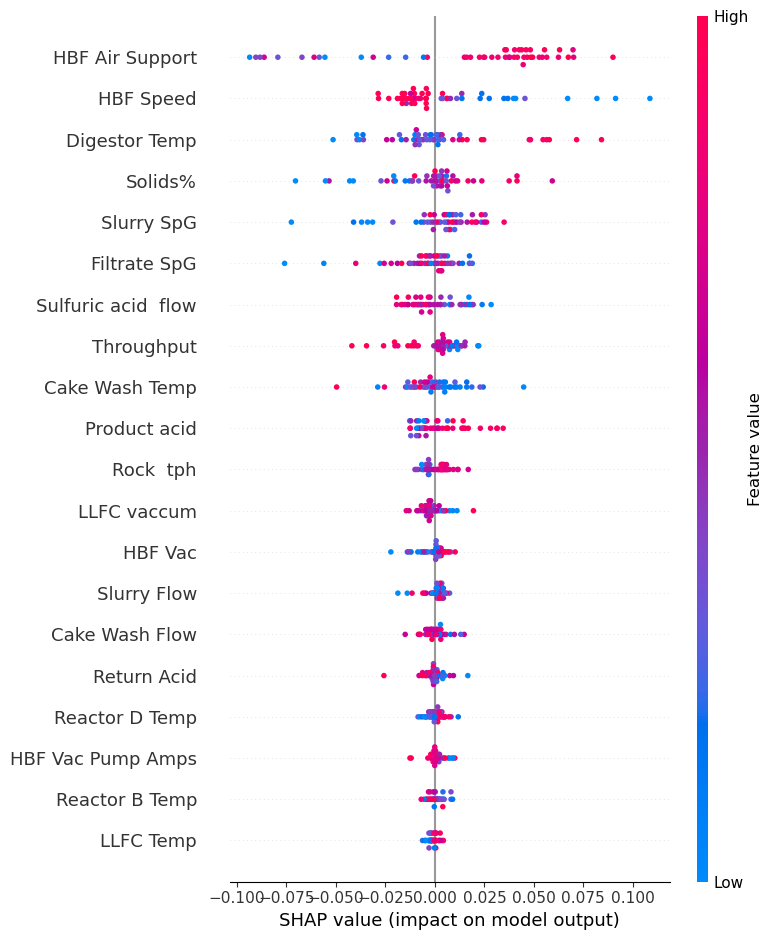

In [123]:
X_sample = X_test.sample(n=50, random_state=42)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

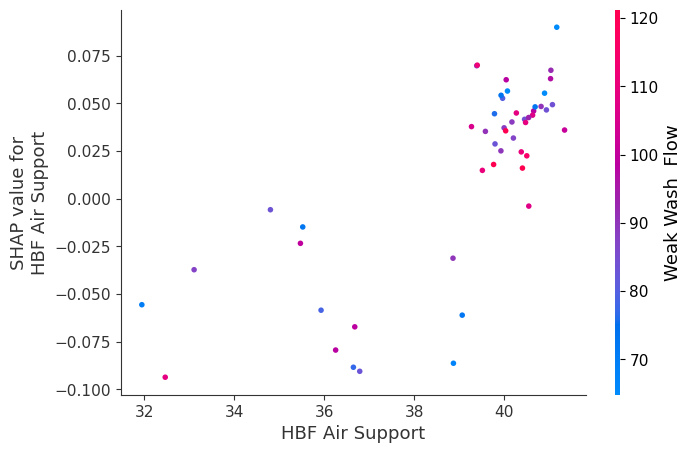

In [ ]:
import shap

shap.dependence_plot(
    "HBF Air Support",
    shap_values,
    X_sample
)u

In [125]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

trees = [10, 20, 50, 100, 150, 200]

results = []

for n in trees:

    model = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = r2_score(y_test, pred)

    results.append([n, score])

for tree, score in results:
    print(f"Trees = {tree:3d}   R² Score = {score:.4f}")

Trees =  10   R² Score = 0.9586
Trees =  20   R² Score = 0.9640
Trees =  50   R² Score = 0.9685
Trees = 100   R² Score = 0.9703
Trees = 150   R² Score = 0.9709
Trees = 200   R² Score = 0.9712


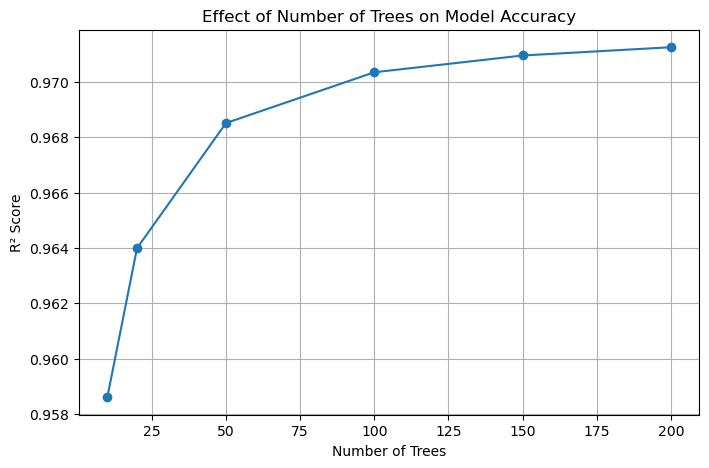

In [126]:
import matplotlib.pyplot as plt

tree_counts = [x[0] for x in results]
scores = [x[1] for x in results]

plt.figure(figsize=(8,5))

plt.plot(tree_counts, scores, marker='o')

plt.xlabel("Number of Trees")

plt.ylabel("R² Score")

plt.title("Effect of Number of Trees on Model Accuracy")

plt.grid(True)

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {

    'n_estimators': [50,100,150],

    'max_depth': [10,20,None],

    'min_samples_split': [2,5,10],

    'min_samples_leaf': [1,2,4]

}

grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1

)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

print("Best Cross Validation Score:", grid.best_score_)